<h1 align="center"><b>DinoSkyNet - Meteor Detection System</b></h1>
<h3 align="center"><b>Data Analysis and Design</b></h3><br>
<h3 align="center"><b>Joel Sierra</b></h3><br>
<h4 align="center"><b>Date: 2025-12-17</b></h4><br>

### **Path Setup**

In [1]:
from pathlib import Path
import random
import sys
import os

# Reproducibility
SEED = 42
random.seed(SEED)

# === Define Storage Paths ===
# Root Path
ROOT = Path(".").resolve().parent

# Core paths
SRC = ROOT / "src"
DATA_SRC = ROOT / "data" / "111_days" / "processed_data"
TRAIN = DATA_SRC / "train"
TEST  =  DATA_SRC / "test"
MODEL_DIR = ROOT / "models"
DATASET_DIR = DATA_SRC / "production_datasets"


# Analysis paths
NOTEBOOK_DIR = ROOT / "notebooks"
NOTE_OUT_DIR = NOTEBOOK_DIR / "outputs"

# Create folders if missing
for d in [SRC, DATA_SRC, MODEL_DIR, DATASET_DIR, NOTEBOOK_DIR, NOTE_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Dino-SkyNet root:", SRC)
print("Data sources:", DATA_SRC.exists())
print("Notebooks:", NOTEBOOK_DIR)

Dino-SkyNet root: /app/src
Data sources: True
Notebooks: /app/notebooks


### **Load Data Sources**

In [2]:
import pandas as pd

COLUMNS = ["frame", "object_id", "x_km", "y_km", "z_km", "wind_x", "wind_y"]

scene_dfs = []
bad_files = []

# Load individual scene text files as DFs
for txt_path in sorted(TRAIN.glob("*.txt")):
    scene_id = int(txt_path.stem)  # Extract scene id

    try:
        df = pd.read_csv(
            txt_path,
            sep=r"\s+",
            header=None,
            names=COLUMNS,
            engine="python",
            comment="#",
        )

        # Import validation
        if df.shape[1] != len(COLUMNS):
            bad_files.append((txt_path.name, df.shape))
            continue

        # Add scene id
        df["scene_id"] = scene_id
        scene_dfs.append(df)

    except Exception as e:
        bad_files.append((txt_path.name, str(e)))

if not scene_dfs:
    raise ValueError("No scene files were loaded.")

train_df = pd.concat(scene_dfs, ignore_index=True)

# Sanity Check
print("Total scenes loaded into main df:", len(scene_dfs))
print("Total main df rows:", train_df.shape[0])
print("Total bad files:", len(bad_files))

if bad_files:
    for item in bad_files[:5]:
        print(" -", item)

train_df.head()

Total scenes loaded into main df: 2230
Total main df rows: 1917017
Total bad files: 0


/tmp/ipykernel_20/745012573.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat(scene_dfs, ignore_index=True)


,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,0,10995703,-4.079537,0.056573,0.57912,0.507009,3.56521,1
1,1,10995703,-4.026575,0.056876,0.56388,0.507009,3.56521,1
2,2,10995703,-3.973612,0.057180,0.54864,0.507009,3.56521,1
3,3,10995703,-3.941283,0.056877,0.54864,0.507009,3.56521,1
4,4,10995703,-3.883392,0.055276,0.54864,0.507009,3.56521,1


In [38]:
# Quick look at dataset
display(train_df.info())
display(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1917017 entries, 0 to 1917016
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   frame      object 
 1   object_id  object 
 2   x_km       float64
 3   y_km       float64
 4   z_km       float64
 5   wind_x     float64
 6   wind_y     float64
 7   scene_id   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 117.0+ MB


None

,x_km,y_km,z_km,wind_x,wind_y,scene_id
count,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06
mean,7.249795e-01,5.690295e-02,5.362047e-01,9.736268e-01,4.751537e-01,1.507982e+03
std,1.906646e+00,1.504641e+00,2.067386e-01,2.484076e+00,1.927122e+00,9.004008e+02
min,-4.131953e+00,-4.890184e+00,0.000000e+00,-7.130419e+00,-6.477846e+00,1.000000e+00
25%,-5.243040e-01,-3.873782e-01,3.657600e-01,-5.070088e-01,-7.988559e-01,6.810000e+02
50%,7.889477e-01,5.166003e-03,5.181600e-01,9.690319e-01,3.195424e-01,1.434000e+03
75%,1.921618e+00,1.856139e-01,6.400800e-01,2.546578e+00,1.938064e+00,2.324000e+03
max,5.866638e+00,5.102012e+00,1.821180e+00,8.802013e+00,8.149050e+00,3.088000e+03


#### **Analyze Single Scene**

In [3]:
scene_id = 42

scene_df = (
    train_df[train_df["scene_id"] == scene_id]
    .sort_values("frame")
    .reset_index(drop=True)
)

scene_df.info()
print()
scene_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   frame      1598 non-null   object 
 1   object_id  1598 non-null   object 
 2   x_km       1598 non-null   float64
 3   y_km       1598 non-null   float64
 4   z_km       1598 non-null   float64
 5   wind_x     1598 non-null   float64
 6   wind_y     1598 non-null   float64
 7   scene_id   1598 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 100.0+ KB



,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,28223,10561439,0.816127,0.206101,0.0000,-5.360128,-4.81042,42
1,28223,10979952,0.876138,-0.020933,0.3048,-5.360128,-4.81042,42
2,28224,10979952,0.901978,-0.020672,0.3048,-5.360128,-4.81042,42
3,28224,10561439,0.815176,0.206995,0.0000,-5.360128,-4.81042,42
4,28225,10561439,0.810992,0.207778,0.0000,-5.360128,-4.81042,42


In [4]:
# Number of unique objects in scene
scene_objects = scene_df["object_id"].unique()

print("Number of unique objects in scene:", len(scene_objects))
display(pd.DataFrame(scene_objects, columns=["Unique Object IDs"]))

Number of unique objects in scene: 5


,Unique Object IDs
0,10561439
1,10979952
2,10764272
3,10942561
4,11374945


In [5]:
# Estimate ADS-B reading range
print("X range:", train_df["x_km"].min(), "to", train_df["x_km"].max())
print("Y range:", train_df["y_km"].min(), "to", train_df["y_km"].max())

X range: -4.131952644032317 to 5.866638491784573
Y range: -4.890183759926705 to 5.102012085564506


### **Plot Trajectory of Single Object**

In [6]:
# Grab object in selected df
obj_id = scene_df["object_id"].unique()[3]

# Filter for object and build df
obj_df = scene_df[scene_df["object_id"] == obj_id]

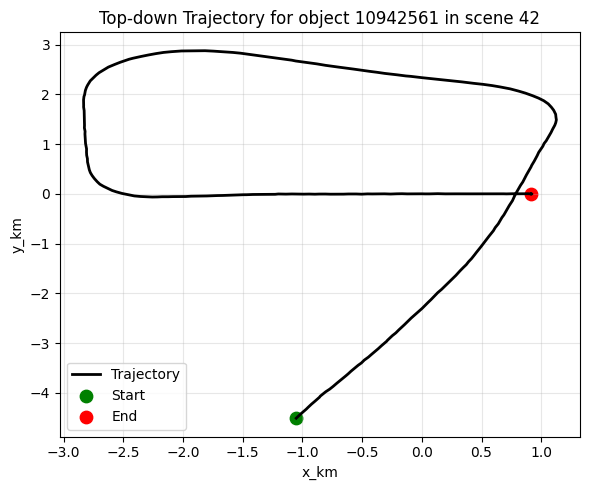

In [7]:
# Plot Top-Down Trajectory
import matplotlib.pyplot as plt

# Sort scene by frame
obj_df = obj_df.sort_values("frame")

# Grab x and y values
x = obj_df["x_km"]
y = obj_df["y_km"]

plt.figure(figsize=(6, 5))

# Plot trajectory
plt.plot(x, y, linewidth=2, color="black", label="Trajectory")

# Plot start and end locations
plt.scatter(x.iloc[0], y.iloc[0], s=80, color="green", label="Start")
plt.scatter(x.iloc[-1], y.iloc[-1], s=80, color="red", label="End")

plt.xlabel("x_km")
plt.ylabel("y_km")
plt.title(f"Top-down Trajectory for object {obj_id} in scene {scene_id}")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

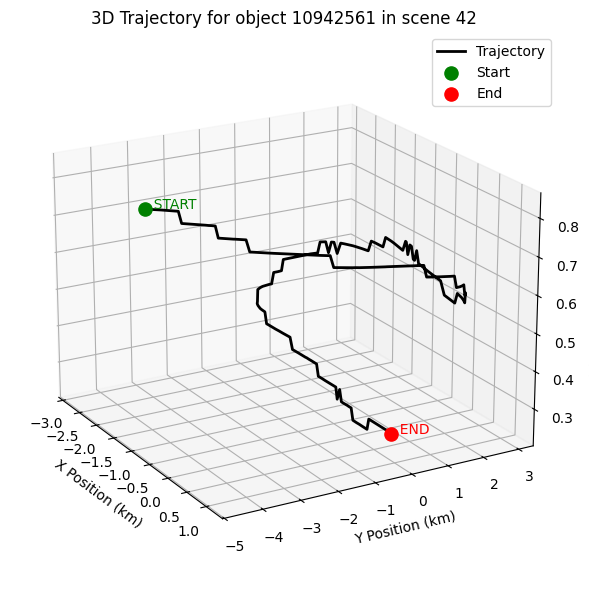

In [8]:
# Plot 3D Trajectory
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# grab positions
x = obj_df["x_km"]
y = obj_df["y_km"]
z = obj_df["z_km"]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot 3D Trajectory
ax.plot(x, y, z, linewidth=2, color="black", label="Trajectory")

# Add starting and ending points to plot
ax.scatter(x.iloc[0], y.iloc[0], z.iloc[0], color="green", s=90, label="Start")
ax.scatter(x.iloc[-1], y.iloc[-1], z.iloc[-1], color="red", s=90, label="End")

# Add labels directly on the points
ax.text(x.iloc[0], y.iloc[0], z.iloc[0], "  START", color="green")
ax.text(x.iloc[-1], y.iloc[-1], z.iloc[-1], "  END", color="red")

ax.set_xlabel("X Position (km)")
ax.set_ylabel("Y Position (km)")
ax.set_zlabel("Altitude Z (km)")
ax.set_title(f"3D Trajectory for object {obj_id} in scene {scene_id}")

# Set Camera angle
ax.view_init(elev=20, azim=-30)

ax.legend()
plt.tight_layout()
plt.show()

### **Plot Trajectory of all Objects in Scene**

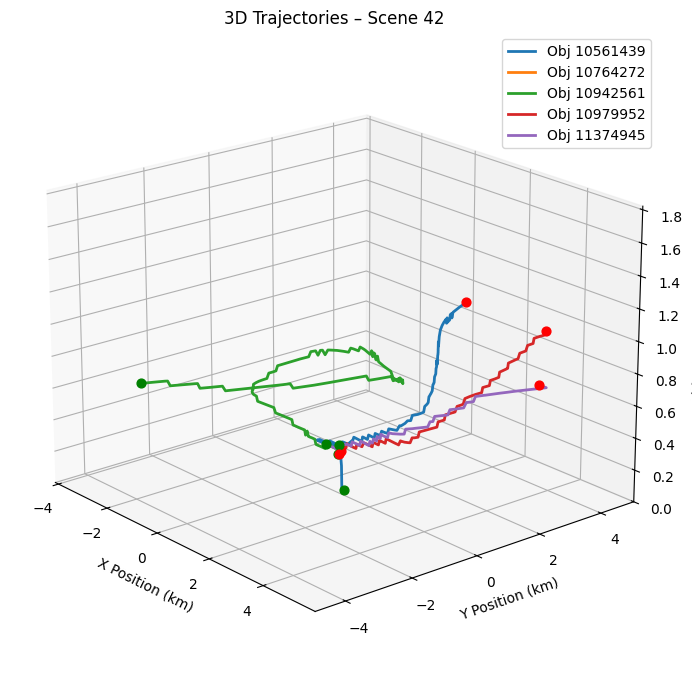

In [9]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Grab ADS-B estimated reading limits
x_min, x_max = train_df["x_km"].min(), train_df["x_km"].max()
y_min, y_max = train_df["y_km"].min(), train_df["y_km"].max()
z_min, z_max = train_df["z_km"].min(), train_df["z_km"].max()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Color map for objects
obj_ids = scene_df["object_id"].unique()
colors = cm.tab10(range(len(obj_ids)))

# Plot objects in scene
for i, (obj_id, obj_data) in enumerate(scene_df.groupby("object_id")):
    obj_data = obj_data.sort_values("frame")  # Sort by frame

    # grab positions
    x = obj_data["x_km"]
    y = obj_data["y_km"]
    z = obj_data["z_km"]

    # Assign color to object
    color = colors[i % len(colors)]

    # Plot Trajectory
    ax.plot(x, y, z, color=color, linewidth=2, label=f"Obj {obj_id}")

    # Plot start and end points
    ax.scatter(x.iloc[0], y.iloc[0], z.iloc[0], color="green", s=40)
    ax.scatter(x.iloc[-1], y.iloc[-1], z.iloc[-1], color="red", s=40)

# Set axis limits per ADS-B reading range
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(z_min, z_max)

# Graph labels
ax.set_xlabel("X Position (km)")
ax.set_ylabel("Y Position (km)")
ax.set_zlabel("Altitude (km)")
ax.set_title(f"3D Trajectories – Scene {scene_id}")

# Set camera angle
ax.view_init(elev=20, azim=-40)


ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Check scenes for object overlap
scene_41 = train_df[train_df["scene_id"] == 41]
scene_42 = train_df[train_df["scene_id"] == 42]
scene_43 = train_df[train_df["scene_id"] == 43]

ids_41 = set(scene_41["object_id"].unique())
ids_42 = set(scene_42["object_id"].unique())
ids_43 = set(scene_43["object_id"].unique())

print("41 and 42 overlap:", ids_41.intersection(ids_42))
print("42 and 43 overlap:", ids_42.intersection(ids_43))
print("41 and 43 overlap:", ids_41.intersection(ids_43))

41 and 42 overlap: {10764272}
42 and 43 overlap: set()
41 and 43 overlap: set()


### **Motion Feature Engineering**

#### **Sort by Object and Time**

We ensure each trajectory is ordered correctly:

$$
(x_t, y_t, z_t) \rightarrow (x_{t+1}, y_{t+1}, z_{t+1})
$$

This allows us to compute position differences between consecutive frames.

In [11]:
# Make a copy of scend df to prototype
scene_features_df = scene_df.sort_values(["object_id", "frame"]).copy()
group_cols = ["object_id"]  # Grab objects to derive features

scene_features_df.head()

,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id
0,28223,10561439,0.816127,0.206101,0.0,-5.360128,-4.81042,42
3,28224,10561439,0.815176,0.206995,0.0,-5.360128,-4.81042,42
4,28225,10561439,0.810992,0.207778,0.0,-5.360128,-4.81042,42
7,28226,10561439,0.811051,0.207961,0.0,-5.360128,-4.81042,42
8,28227,10561439,0.811111,0.208144,0.0,-5.360128,-4.81042,42


### Compute Position Differences (First-Order)

We compute changes in position between consecutive frames:

$$
\Delta x_t = x_t - x_{t-1}, \quad
\Delta y_t = y_t - y_{t-1}, \quad
\Delta z_t = z_t - z_{t-1}
$$

From the README we know data is sampled at 1 Hz:

$$
v_x = \frac{\Delta x}{\Delta t} = \Delta x
$$

So **position differences directly represent velocity**.

In [12]:
scene_features_df["dx"] = scene_features_df.groupby(group_cols)["x_km"].diff()
scene_features_df["dy"] = scene_features_df.groupby(group_cols)["y_km"].diff()
scene_features_df["dz"] = scene_features_df.groupby(group_cols)["z_km"].diff()

scene_features_df[["dx", "dy", "dz"]].head()

,dx,dy,dz
0,NaN,NaN,NaN
3,-0.000951,0.000895,0.0
4,-0.004185,0.000783,0.0
7,0.000060,0.000183,0.0
8,0.000060,0.000183,0.0


### Add Velocity Components

Each frame now contains velocity too:

$$
v_t = (v_x, v_y, v_z)
$$

In [14]:
scene_features_df["vx_km_s"] = scene_features_df["dx"]
scene_features_df["vy_km_s"] = scene_features_df["dy"]
scene_features_df["vz_km_s"] = scene_features_df["dz"]

scene_features_df[["frame", "object_id", "vx_km_s", "vy_km_s", "vz_km_s"]].head()

,frame,object_id,vx_km_s,vy_km_s,vz_km_s
0,28223,10561439,NaN,NaN,NaN
3,28224,10561439,-0.000951,0.000895,0.0
4,28225,10561439,-0.004185,0.000783,0.0
7,28226,10561439,0.000060,0.000183,0.0
8,28227,10561439,0.000060,0.000183,0.0


### Compute Speed (Magnitude of Velocity)

Horizontal speed:

$$
v_{xy} = \sqrt{v_x^2 + v_y^2}
$$

Full 3D speed:

$$
v = \sqrt{v_x^2 + v_y^2 + v_z^2}
$$

In [19]:
import numpy as np

scene_features_df["horizontal_speed_km_s"] = np.sqrt(
    scene_features_df["vx_km_s"]**2 + scene_features_df["vy_km_s"]**2
)

scene_features_df["speed_3d_km_s"] = np.sqrt(
    scene_features_df["vx_km_s"]**2
    + scene_features_df["vy_km_s"]**2
    + scene_features_df["vz_km_s"]**2
)

scene_features_df[["frame", "object_id", "horizontal_speed_km_s", "speed_3d_km_s"]][580:586]

,frame,object_id,horizontal_speed_km_s,speed_3d_km_s
1509,28948,10561439,0.036254,0.036254
1510,28949,10561439,0.053094,0.053094
1511,28950,10561439,0.053094,0.053094
1512,28951,10561439,0.056914,0.064562
1513,28952,10561439,0.048610,0.057376
1514,28953,10561439,0.021797,0.037472


### Compute Acceleration (Second-Order Differences)

We compute changes in velocity:

$$
a_x = v_{x,t} - v_{x,t-1}
$$

Full acceleration magnitude:

$$
a = \sqrt{a_x^2 + a_y^2 + a_z^2}
$$

In [20]:
scene_features_df["ax_km_s2"] = scene_features_df.groupby(group_cols)["vx_km_s"].diff()
scene_features_df["ay_km_s2"] = scene_features_df.groupby(group_cols)["vy_km_s"].diff()
scene_features_df["az_km_s2"] = scene_features_df.groupby(group_cols)["vz_km_s"].diff()

scene_features_df["accel_3d_km_s2"] = np.sqrt(
    scene_features_df["ax_km_s2"]**2
    + scene_features_df["ay_km_s2"]**2
    + scene_features_df["az_km_s2"]**2
)

scene_features_df[["ax_km_s2", "ay_km_s2", "az_km_s2", "accel_3d_km_s2"]].head()

,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2
0,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,-3.233591e-03,-1.117202e-04,0.0,3.235521e-03
7,4.244215e-03,-6.004278e-04,0.0,4.286475e-03
8,1.110223e-16,2.775558e-17,0.0,1.144392e-16


### Compute Descent Rate

We define descent rate as:

$$
\text{descent rate} = -v_z
$$

So:
- Positive is moving downward  
- Negative is climbing upwards

In [23]:
scene_features_df["descent_rate_km_s"] = -scene_features_df["vz_km_s"]

scene_features_df[["frame", "object_id", "vz_km_s", "descent_rate_km_s"]][580:586]

,frame,object_id,vz_km_s,descent_rate_km_s
1509,28948,10561439,0.00000,-0.00000
1510,28949,10561439,0.00000,-0.00000
1511,28950,10561439,0.00000,-0.00000
1512,28951,10561439,-0.03048,0.03048
1513,28952,10561439,0.03048,-0.03048
1514,28953,10561439,-0.03048,0.03048


### Handling Missing Values

The first frame per object has no previous timestep so NaN were assigned by some of the previous calculations:

$$
\text{diff} \rightarrow \text{NaN}
$$

We replace these with 0 for consistency.

In [24]:
scene_features_df = scene_features_df.fillna(0)

scene_features_df.head()

/tmp/ipykernel_20/3840179723.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  scene_features_df = scene_features_df.fillna(0)


,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id,dx,dy,...,vx_km_s,vy_km_s,vz_km_s,horizontal_speed_km_s,speed_3d_km_s,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2,descent_rate_km_s
0,28223,10561439,0.816127,0.206101,0.0,-5.360128,-4.81042,42,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0
3,28224,10561439,0.815176,0.206995,0.0,-5.360128,-4.81042,42,-0.000951,0.000895,...,-0.000951,0.000895,0.0,0.001306,0.001306,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-0.0
4,28225,10561439,0.810992,0.207778,0.0,-5.360128,-4.81042,42,-0.004185,0.000783,...,-0.004185,0.000783,0.0,0.004257,0.004257,-3.233591e-03,-1.117202e-04,0.0,3.235521e-03,-0.0
7,28226,10561439,0.811051,0.207961,0.0,-5.360128,-4.81042,42,0.000060,0.000183,...,0.000060,0.000183,0.0,0.000192,0.000192,4.244215e-03,-6.004278e-04,0.0,4.286475e-03,-0.0
8,28227,10561439,0.811111,0.208144,0.0,-5.360128,-4.81042,42,0.000060,0.000183,...,0.000060,0.000183,0.0,0.000192,0.000192,1.110223e-16,2.775558e-17,0.0,1.144392e-16,-0.0


### Add Motion Features to Training Dataset

#### Define `add_motion_features` Function

In [25]:
import numpy as np
import pandas as pd

def add_motion_features(
    df: pd.DataFrame,
    group_cols: list[str] = ["scene_id", "object_id"],
    fill_missing: bool = True,
) -> pd.DataFrame:
    """
    Add per-frame motion features to the full trajectory dataset.

    Assumes the data is sampled at 1 Hz, so position differences in km
    directly represent velocity in km/s.
    """

    # Work on a copy so the original dataframe is not modified
    features_df = df.sort_values(group_cols + ["frame"]).copy()

    # Position differences
    features_df["dx"] = features_df.groupby(group_cols)["x_km"].diff()
    features_df["dy"] = features_df.groupby(group_cols)["y_km"].diff()
    features_df["dz"] = features_df.groupby(group_cols)["z_km"].diff()

    # Velocity components
    features_df["vx_km_s"] = features_df["dx"]
    features_df["vy_km_s"] = features_df["dy"]
    features_df["vz_km_s"] = features_df["dz"]

    # Speed features
    features_df["horizontal_speed_km_s"] = np.sqrt(
        features_df["vx_km_s"]**2 + features_df["vy_km_s"]**2
    )

    features_df["speed_3d_km_s"] = np.sqrt(
        features_df["vx_km_s"]**2
        + features_df["vy_km_s"]**2
        + features_df["vz_km_s"]**2
    )

    # Acceleration components
    features_df["ax_km_s2"] = features_df.groupby(group_cols)["vx_km_s"].diff()
    features_df["ay_km_s2"] = features_df.groupby(group_cols)["vy_km_s"].diff()
    features_df["az_km_s2"] = features_df.groupby(group_cols)["vz_km_s"].diff()

    features_df["accel_3d_km_s2"] = np.sqrt(
        features_df["ax_km_s2"]**2
        + features_df["ay_km_s2"]**2
        + features_df["az_km_s2"]**2
    )

    # Positive means moving downward
    features_df["descent_rate_km_s"] = -features_df["vz_km_s"]

    # add meters per-second-units
    features_df["horizontal_speed_m_s"] = features_df["horizontal_speed_km_s"] * 1000
    features_df["speed_3d_m_s"] = features_df["speed_3d_km_s"] * 1000
    features_df["accel_3d_m_s2"] = features_df["accel_3d_km_s2"] * 1000
    features_df["descent_rate_m_s"] = features_df["descent_rate_km_s"] * 1000

    if fill_missing:
        feature_cols = [
            "dx", "dy", "dz",
            "vx_km_s", "vy_km_s", "vz_km_s",
            "horizontal_speed_km_s", "speed_3d_km_s",
            "ax_km_s2", "ay_km_s2", "az_km_s2",
            "accel_3d_km_s2",
            "descent_rate_km_s",
            "horizontal_speed_m_s", "speed_3d_m_s",
            "accel_3d_m_s2", "descent_rate_m_s",
        ]

        features_df[feature_cols] = features_df[feature_cols].fillna(0)

    return features_df

#### Add Motion Features to Training Dataset

In [26]:
train_features_df = add_motion_features(train_df)

print("Original shape:", train_df.shape)
print("Feature shape:", train_features_df.shape)

train_features_df.head()

Original shape: (1917017, 8)
Feature shape: (1917017, 25)


,frame,object_id,x_km,y_km,z_km,wind_x,wind_y,scene_id,dx,dy,...,speed_3d_km_s,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2,descent_rate_km_s,horizontal_speed_m_s,speed_3d_m_s,accel_3d_m_s2,descent_rate_m_s
0,0,10995703,-4.079537,0.056573,0.57912,0.507009,3.56521,1,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000e+00,0.00
1,1,10995703,-4.026575,0.056876,0.56388,0.507009,3.56521,1,0.052962,0.000303,...,0.055112,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.01524,52.963315,55.112342,0.000000e+00,15.24
2,2,10995703,-3.973612,0.057180,0.54864,0.507009,3.56521,1,0.052962,0.000303,...,0.055112,8.881784e-16,6.938894e-18,1.110223e-16,8.951173e-16,0.01524,52.963315,55.112342,8.951173e-13,15.24
3,3,10995703,-3.941283,0.056877,0.54864,0.507009,3.56521,1,0.032329,-0.000302,...,0.032331,-2.063296e-02,-6.055856e-04,1.524000e-02,2.565820e-02,-0.00000,32.330900,32.330900,2.565820e+01,-0.00
4,4,10995703,-3.883392,0.055276,0.54864,0.507009,3.56521,1,0.057891,-0.001601,...,0.057913,2.556149e-02,-1.299175e-03,0.000000e+00,2.559448e-02,-0.00000,57.913123,57.913123,2.559448e+01,-0.00


#### Sanity Check: Prototype Dataset V. Updated Training Dataset

In [28]:
# Compare same scene/object/frame rows from prototyping dataset
check_rows = scene_features_df.head()[["scene_id", "object_id", "frame"]]

prototype_check = scene_features_df.merge(
    check_rows,
    on=["scene_id", "object_id", "frame"],
    how="inner"
)

full_check = train_features_df.merge(
    check_rows,
    on=["scene_id", "object_id", "frame"],
    how="inner"
)

cols_to_check = [
    "scene_id", "object_id", "frame",
    "dx", "dy", "dz",
    "vx_km_s", "vy_km_s", "vz_km_s",
    "speed_3d_km_s",
    "accel_3d_km_s2",
    "descent_rate_km_s"
]

print("Prototype rows:")
display(prototype_check[cols_to_check])

print("Full pipeline rows:")
display(full_check[cols_to_check])

Prototype rows:


,scene_id,object_id,frame,dx,dy,dz,vx_km_s,vy_km_s,vz_km_s,speed_3d_km_s,accel_3d_km_s2,descent_rate_km_s
0,42,10561439,28223,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.0
1,42,10561439,28224,-0.000951,0.000895,0.0,-0.000951,0.000895,0.0,0.001306,0.000000e+00,-0.0
2,42,10561439,28225,-0.004185,0.000783,0.0,-0.004185,0.000783,0.0,0.004257,3.235521e-03,-0.0
3,42,10561439,28226,0.000060,0.000183,0.0,0.000060,0.000183,0.0,0.000192,4.286475e-03,-0.0
4,42,10561439,28227,0.000060,0.000183,0.0,0.000060,0.000183,0.0,0.000192,1.144392e-16,-0.0


Full pipeline rows:


,scene_id,object_id,frame,dx,dy,dz,vx_km_s,vy_km_s,vz_km_s,speed_3d_km_s,accel_3d_km_s2,descent_rate_km_s
0,42,10561439,28223,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000e+00,0.0
1,42,10561439,28224,-0.000951,0.000895,0.0,-0.000951,0.000895,0.0,0.001306,0.000000e+00,-0.0
2,42,10561439,28225,-0.004185,0.000783,0.0,-0.004185,0.000783,0.0,0.004257,3.235521e-03,-0.0
3,42,10561439,28226,0.000060,0.000183,0.0,0.000060,0.000183,0.0,0.000192,4.286475e-03,-0.0
4,42,10561439,28227,0.000060,0.000183,0.0,0.000060,0.000183,0.0,0.000192,1.144392e-16,-0.0


### Exploratory Data Analysis

#### Initial Look at Dataset

In [39]:
print("Shape:", train_features_df.shape)
print()
display(train_features_df.info())
display(train_features_df.describe())

Shape: (1917017, 25)

<class 'pandas.core.frame.DataFrame'>
Index: 1917017 entries, 0 to 1422616
Data columns (total 25 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   frame                  object 
 1   object_id              object 
 2   x_km                   float64
 3   y_km                   float64
 4   z_km                   float64
 5   wind_x                 float64
 6   wind_y                 float64
 7   scene_id               int64  
 8   dx                     float64
 9   dy                     float64
 10  dz                     float64
 11  vx_km_s                float64
 12  vy_km_s                float64
 13  vz_km_s                float64
 14  horizontal_speed_km_s  float64
 15  speed_3d_km_s          float64
 16  ax_km_s2               float64
 17  ay_km_s2               float64
 18  az_km_s2               float64
 19  accel_3d_km_s2         float64
 20  descent_rate_km_s      float64
 21  horizontal_speed_m_s   float64
 22  s

None

,x_km,y_km,z_km,wind_x,wind_y,scene_id,dx,dy,dz,vx_km_s,...,speed_3d_km_s,ax_km_s2,ay_km_s2,az_km_s2,accel_3d_km_s2,descent_rate_km_s,horizontal_speed_m_s,speed_3d_m_s,accel_3d_m_s2,descent_rate_m_s
count,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,...,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06,1.917017e+06
mean,7.249795e-01,5.690295e-02,5.362047e-01,9.736268e-01,4.751537e-01,1.507982e+03,-2.696828e-04,6.427293e-04,1.580490e-04,-2.696828e-04,...,3.458723e-02,-3.955119e-06,8.177018e-06,-1.823202e-06,1.164428e-02,-1.580490e-04,3.406880e+01,3.458723e+01,1.164428e+01,-1.580490e-01
std,1.906646e+00,1.504641e+00,2.067386e-01,2.484076e+00,1.927122e+00,9.004008e+02,4.758315e-02,3.603803e-02,7.353001e-03,4.758315e-02,...,4.920565e-02,4.995905e-02,4.089590e-02,1.023566e-02,6.432387e-02,7.353001e-03,4.901732e+01,4.920565e+01,6.432387e+01,7.353001e+00
min,-4.131953e+00,-4.890184e+00,0.000000e+00,-7.130419e+00,-6.477846e+00,1.000000e+00,-8.859074e+00,-9.397066e+00,-6.705600e-01,-8.859074e+00,...,0.000000e+00,-9.812603e+00,-9.389216e+00,-6.705600e-01,0.000000e+00,-6.705600e-01,0.000000e+00,0.000000e+00,0.000000e+00,-6.705600e+02
25%,-5.243040e-01,-3.873782e-01,3.657600e-01,-5.070088e-01,-7.988559e-01,6.810000e+02,-2.747325e-02,-3.069908e-03,0.000000e+00,-2.747325e-02,...,1.865247e-02,-1.728155e-03,-1.133906e-03,0.000000e+00,2.497993e-16,0.000000e+00,1.833024e+01,1.865247e+01,2.497993e-13,0.000000e+00
50%,7.889477e-01,5.166003e-03,5.181600e-01,9.690319e-01,3.195424e-01,1.434000e+03,-2.089608e-05,-2.200143e-07,0.000000e+00,-2.089608e-05,...,3.659108e-02,0.000000e+00,0.000000e+00,0.000000e+00,4.552874e-03,0.000000e+00,3.600492e+01,3.659108e+01,4.552874e+00,0.000000e+00
75%,1.921618e+00,1.856139e-01,6.400800e-01,2.546578e+00,1.938064e+00,2.324000e+03,2.418698e-02,3.864039e-03,0.000000e+00,2.418698e-02,...,4.804350e-02,1.732139e-03,1.164212e-03,0.000000e+00,1.603926e-02,0.000000e+00,4.734685e+01,4.804350e+01,1.603926e+01,0.000000e+00
max,5.866638e+00,5.102012e+00,1.821180e+00,8.802013e+00,8.149050e+00,3.088000e+03,9.764328e+00,7.486062e+00,6.705600e-01,9.764328e+00,...,9.799174e+00,9.761324e+00,9.446084e+00,1.341120e+00,9.847647e+00,6.705600e-01,9.798615e+03,9.799174e+03,9.847647e+03,6.705600e+02


#### Visualize Derived Features

#### Plot Histogram

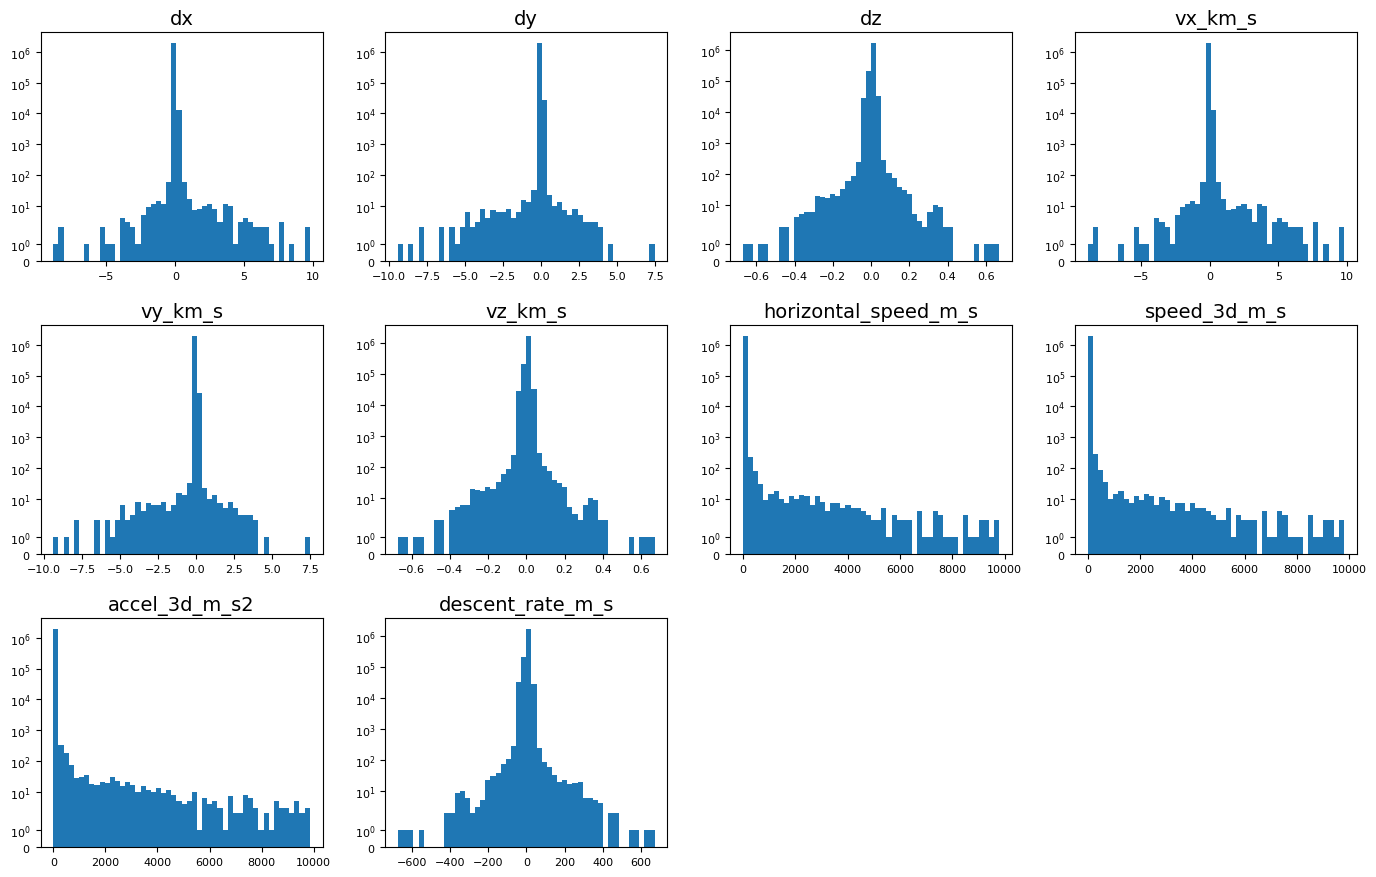

In [34]:
import matplotlib.pyplot as plt

feature_cols = [
    "dx", "dy", "dz",
    "vx_km_s", "vy_km_s", "vz_km_s",
    "horizontal_speed_m_s", "speed_3d_m_s",
    "accel_3d_m_s2", "descent_rate_m_s"
]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    ax.hist(train_features_df[col], bins=50)
    ax.set_title(col)
    
    # Use symmetric log scale to handle wide range + negatives
    ax.set_yscale("symlog")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Key Observations

- Most position changes and velocities are **very small and close to 0**, which means aircraft move smoothly from one second to the next.
- Horizontal movement (**vx, vy**) looks balanced and consistent in both directions.
- Vertical movement (**vz**) stays close to 0 most of the time, meaning aircraft usually fly at a **steady altitude**.
- Speed values are mostly low, with some higher values, which matches normal flight behavior.
- Descent rate is centered around 0, meaning aircraft spend similar time **going up and going down**.
- Acceleration is usually small, but there are some **large spikes**. This happens because acceleration is based on changes in velocity, so even small frame-to-frame variations can appear as larger jumps.
- There are a few **very large values** (especially in speed and acceleration). These likely come from brief inconsistencies in the data, such as sudden jumps in position between frames.

##### Feature Distibutions
- Some features (like dx, dy, vx, vy) are centered around 0 and look pretty balanced on both sides and have a **Gaussian (normal) distribution**.  
- Other features (like speed and acceleration) are **right-skewed**, meaning most values are small, but there are a few much larger ones. This makes sense since aircraft usually move smoothly, but occasionally you’ll accelarte and you see bigger changes.  
- These long right tails are basically showing those **rare larger values**. They could be real behavior (like sharper turns or climbs), but some of them are probably just small inconsistencies in the data getting amplified thru the feature engineering.

---

#### Takeaway

- The dataset shows **realistic aircraft movement overall**
- Minor data cleaning is needed before training the model
- 'Meteor-like' datapoints will need to be engineered and labeled

#### Correlation HeatMap

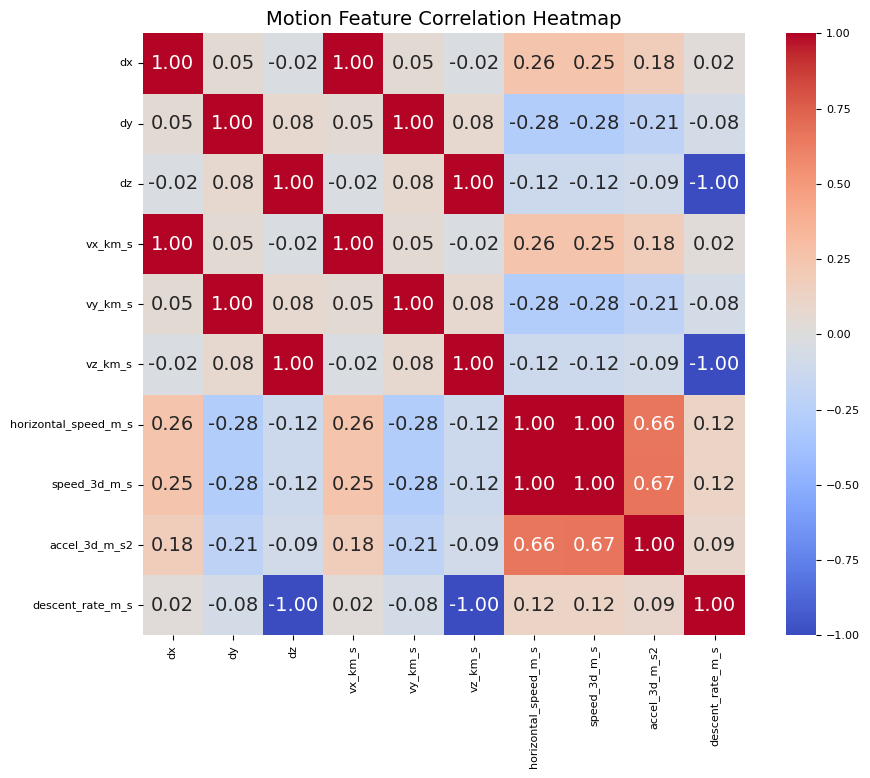

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select motion features only
motion_cols = [
    "dx", "dy", "dz",
    "vx_km_s", "vy_km_s", "vz_km_s",
    "horizontal_speed_m_s", "speed_3d_m_s",
    "accel_3d_m_s2", "descent_rate_m_s"
]

# Compute correlation matrix
corr = train_features_df[motion_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Motion Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

##### Correlation Observations  

- dx ~ vx, dy ~ vy, dz ~ vz, this is expected since velocity is derived from position.
- Horizontal and 3D speed are highly correlated and are mostly redundant.
- Descent rate is perfectly tied to vertical velocity (vz), again expected becaouse of the way it was derived.